# 02 - Modeling & Benchmark

## Objetivo do benchmark
Comparar modelos de famílias diferentes para identificar qual representa melhor o problema de inadimplência.

## Por que comparar famílias diferentes
- Regressão Logística: baseline linear e interpretável
- Random Forest: modelo não linear robusto
- LightGBM: modelo forte para dados tabulares


In [1]:
import json
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import METRICS_DIR, METRICS_RUNS_DIR, FIG_RUNS_DIR, MODEL_COMPARISON_PATH

MODEL_INFO_PATH = METRICS_DIR / 'model_info.json'


In [2]:
RUN_PIPELINE = False

if RUN_PIPELINE:
    subprocess.run([sys.executable, '-m', 'src.train'], check=True)
    subprocess.run([sys.executable, '-m', 'src.evaluate'], check=True)

comparison = pd.read_csv(MODEL_COMPARISON_PATH)
comparison = comparison.sort_values(['pr_auc', 'roc_auc'], ascending=False).reset_index(drop=True)

if MODEL_INFO_PATH.exists():
    model_info = json.loads(MODEL_INFO_PATH.read_text(encoding='utf-8'))
else:
    model_info = {}

display(comparison.head())
print('best_run_id (model_info):', model_info.get('best_run_id'))


,run_id,model_key,model_name,use_smote,roc_auc,pr_auc,f1_at_05,best_threshold,f1_best_threshold,precision_best_threshold,recall_best_threshold,positive_rate_best_threshold,cv_roc_auc_mean,cv_pr_auc_mean,run_fig_dir,run_val_pred_path,run_model_path
0,71dc896c6e4d483dacc7c2d9ed7867fd,rf,Random Forest,0,0.960071,0.724848,0.559838,0.20,0.669410,0.620865,0.726190,0.077914,0.964129,0.754422,\Case Prático Datarisk...,\Case Prático Datarisk...,\Case Prático Datarisk...
1,e47191debe45409cb378d4b464d5af68,rf,Random Forest,1,0.951144,0.683565,0.662088,0.50,0.662088,0.614796,0.717262,0.077716,0.960325,0.738986,\Case Prático Datarisk...,\Case Prático Datarisk...,\Case Prático Datarisk...
2,68119573826e49faaf36daa46e7fc24f,lgbm,LightGBM,0,0.932089,0.681180,0.597082,0.60,0.630102,0.551339,0.735119,0.088818,0.953745,0.721734,\Case Prático Datarisk...,\Case Prático Datarisk...,\Case Prático Datarisk...
3,c7b488d2d5364bf2b744c07fcb2baa0d,logreg,Logistic Regression,0,0.836098,0.346570,0.318606,0.70,0.463576,0.368421,0.625000,0.113006,0.847718,0.337721,\Case Prático Datarisk...,\Case Prático Datarisk...,\Case Prático Datarisk...
4,bc6997f992bc465cb53b10ee23e1cc00,logreg,Logistic Regression,1,0.812186,0.334105,0.324361,0.65,0.433468,0.327744,0.639881,0.130056,0.833587,0.338581,\Case Prático Datarisk...,\Case Prático Datarisk...,\Case Prático Datarisk...


best_run_id (model_info): 71dc896c6e4d483dacc7c2d9ed7867fd


## Estratégia de validação

- **Holdout temporal**: as safras mais recentes são separadas para validação, reduzindo vazamento temporal.
- **CV complementar**: cross-validation estratificada no treino para estabilidade de estimativa.
- **Por que melhor que split aleatório**: em inadimplência, o tempo importa; split aleatório pode superestimar performance ao misturar períodos.


In [3]:
bench = comparison.copy()
bench.insert(0, 'rank', np.arange(1, len(bench) + 1))
bench['variant'] = bench['use_smote'].astype(int).map({1: 'with SMOTE', 0: 'without SMOTE'})

cols = [
    'rank', 'model_name', 'variant', 'pr_auc', 'roc_auc', 'f1_at_05',
    'best_threshold', 'f1_best_threshold', 'precision_best_threshold',
    'recall_best_threshold', 'positive_rate_best_threshold'
]
bench = bench[cols].rename(columns={
    'model_name': 'model',
    'pr_auc': 'PR-AUC',
    'roc_auc': 'ROC-AUC',
    'f1_at_05': 'F1@0.5',
    'best_threshold': 'best_threshold',
    'f1_best_threshold': 'best_F1',
    'precision_best_threshold': 'precision@best',
    'recall_best_threshold': 'recall@best',
    'positive_rate_best_threshold': 'positive_rate@best',
})

display(bench)


,rank,model,variant,PR-AUC,ROC-AUC,F1@0.5,best_threshold,best_F1,precision@best,recall@best,positive_rate@best
0,1,Random Forest,without SMOTE,0.724848,0.960071,0.559838,0.20,0.669410,0.620865,0.726190,0.077914
1,2,Random Forest,with SMOTE,0.683565,0.951144,0.662088,0.50,0.662088,0.614796,0.717262,0.077716
2,3,LightGBM,without SMOTE,0.681180,0.932089,0.597082,0.60,0.630102,0.551339,0.735119,0.088818
3,4,Logistic Regression,without SMOTE,0.346570,0.836098,0.318606,0.70,0.463576,0.368421,0.625000,0.113006
4,5,Logistic Regression,with SMOTE,0.334105,0.812186,0.324361,0.65,0.433468,0.327744,0.639881,0.130056


## Discussao do benchmark

- **Logistic Regression (baseline)**: serve para testar se um modelo linear simples já explicaria bem o problema.
- **Random Forest**: captura interações e não linearidades com robustez.
- **LightGBM**: maior capacidade para padrões tabulares complexos.

Quando a Regressão Logística fica consistentemente atrás, a leitura técnica natural e: a estrutura do problema não e bem capturada por relações lineares/aditivas, e modelos de árvore se ajustam melhor ao comportamento observado.


,threshold,precision,recall,f1,positive_rate
0,0.05,0.284827,0.955357,0.438824,0.223434
1,0.10,0.442396,0.857143,0.583587,0.129064
2,0.15,0.546025,0.776786,0.641278,0.094766
3,0.20,0.620865,0.726190,0.669410,0.077914
4,0.25,0.655977,0.669643,0.662739,0.068002


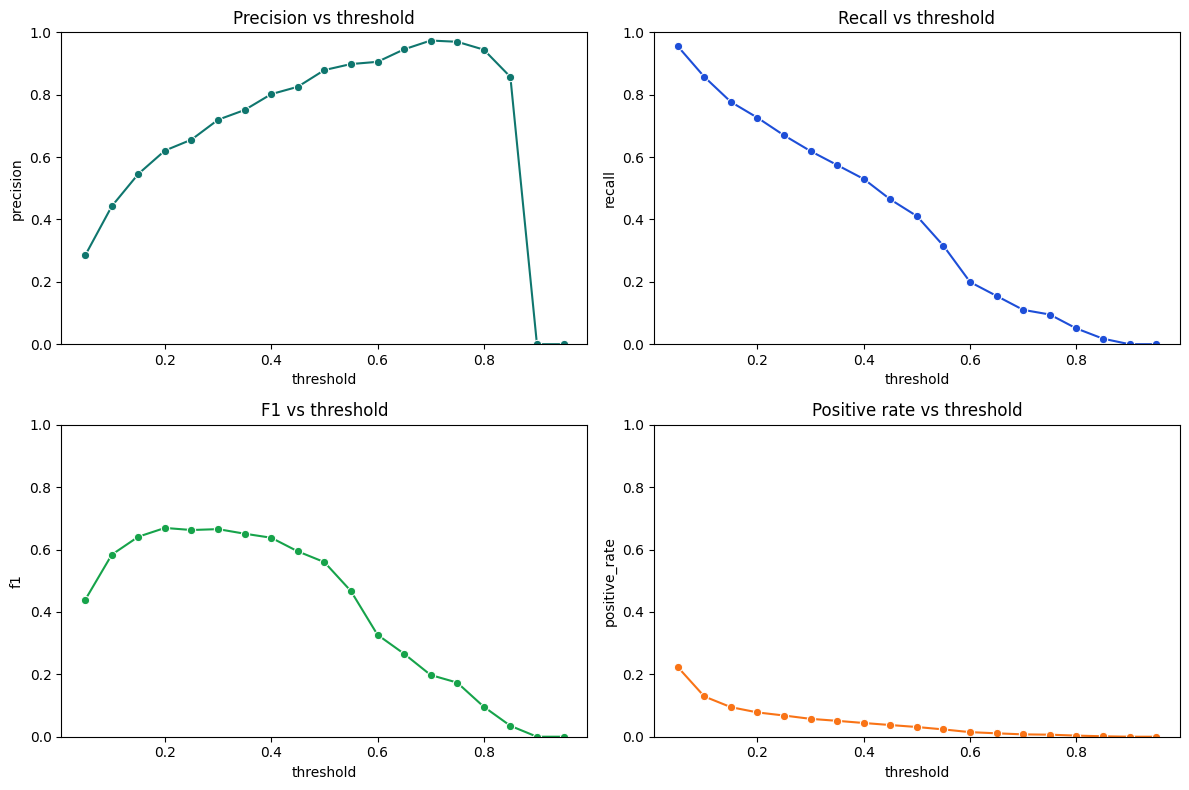

In [4]:
best_run_id = str(model_info.get('best_run_id', comparison.iloc[0]['run_id']))
val_path = METRICS_RUNS_DIR / f'val_predictions_{best_run_id}.csv'
val_pred = pd.read_csv(val_path)

y_true = val_pred['y_true'].astype(int).values
y_prob = val_pred['y_prob'].astype(float).values

rows = []
for thr in np.linspace(0.05, 0.95, 19):
    y_hat = (y_prob >= thr).astype(int)
    tp = ((y_true == 1) & (y_hat == 1)).sum()
    tn = ((y_true == 0) & (y_hat == 0)).sum()
    fp = ((y_true == 0) & (y_hat == 1)).sum()
    fn = ((y_true == 1) & (y_hat == 0)).sum()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    pos_rate = (y_hat == 1).mean()
    rows.append({'threshold': thr, 'precision': precision, 'recall': recall, 'f1': f1, 'positive_rate': pos_rate})

thr_df = pd.DataFrame(rows)
display(thr_df.head())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.lineplot(data=thr_df, x='threshold', y='precision', marker='o', ax=axes[0, 0], color='#0F766E')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title('Precision vs threshold')

sns.lineplot(data=thr_df, x='threshold', y='recall', marker='o', ax=axes[0, 1], color='#1D4ED8')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title('Recall vs threshold')

sns.lineplot(data=thr_df, x='threshold', y='f1', marker='o', ax=axes[1, 0], color='#16A34A')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].set_title('F1 vs threshold')

sns.lineplot(data=thr_df, x='threshold', y='positive_rate', marker='o', ax=axes[1, 1], color='#F97316')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title('Positive rate vs threshold')

for ax in axes.ravel():
    ax.set_xlabel('threshold')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


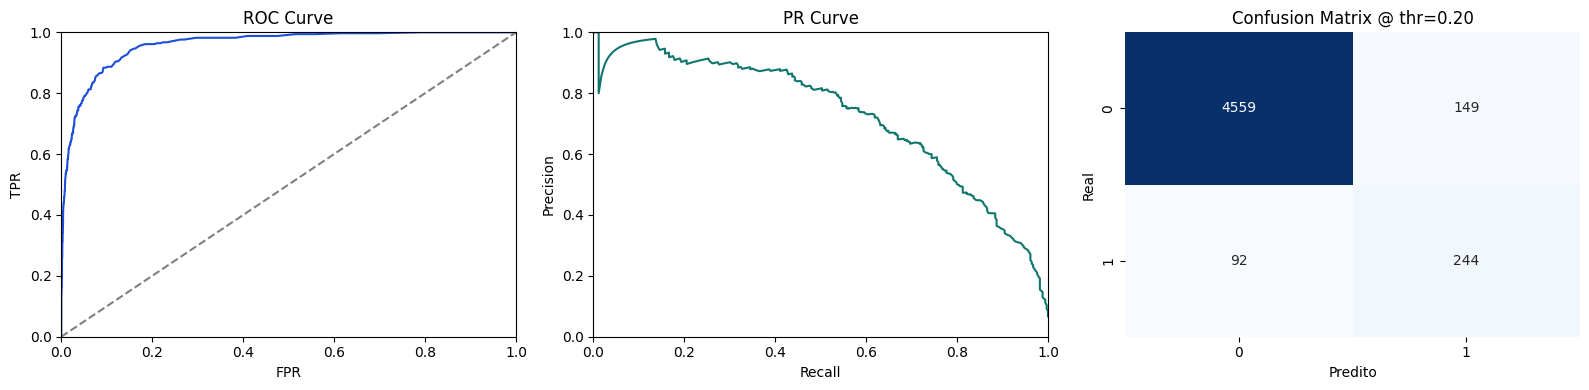

In [5]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
prec, rec, _ = precision_recall_curve(y_true, y_prob)

best_thr = float(thr_df.loc[thr_df['f1'].idxmax(), 'threshold'])
y_best = (y_prob >= best_thr).astype(int)
cm = confusion_matrix(y_true, y_best)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(fpr, tpr, color='#1D4ED8')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

axes[1].plot(rec, prec, color='#0F766E')
axes[1].set_title('PR Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[2])
axes[2].set_title(f'Confusion Matrix @ thr={best_thr:.2f}')
axes[2].set_xlabel('Predito')
axes[2].set_ylabel('Real')

plt.tight_layout()
plt.show()


,feature,importance,rank
0,QTDE_ATRASOS_ANT,0.183702,1
1,VALOR_A_PAGAR,0.119621,2
2,PRAZO_EMISSAO_VENCIMENTO,0.097502,3
3,VALOR_RELATIVO_RENDA,0.076202,4
4,TICKET_MEDIO_ANT,0.071685,5
5,TEMPO_CADASTRO,0.063007,6
6,RENDA_MES_ANTERIOR,0.049552,7
7,NO_FUNCIONARIOS,0.039802,8
8,MES,0.029631,9
9,TAXA,0.018231,10


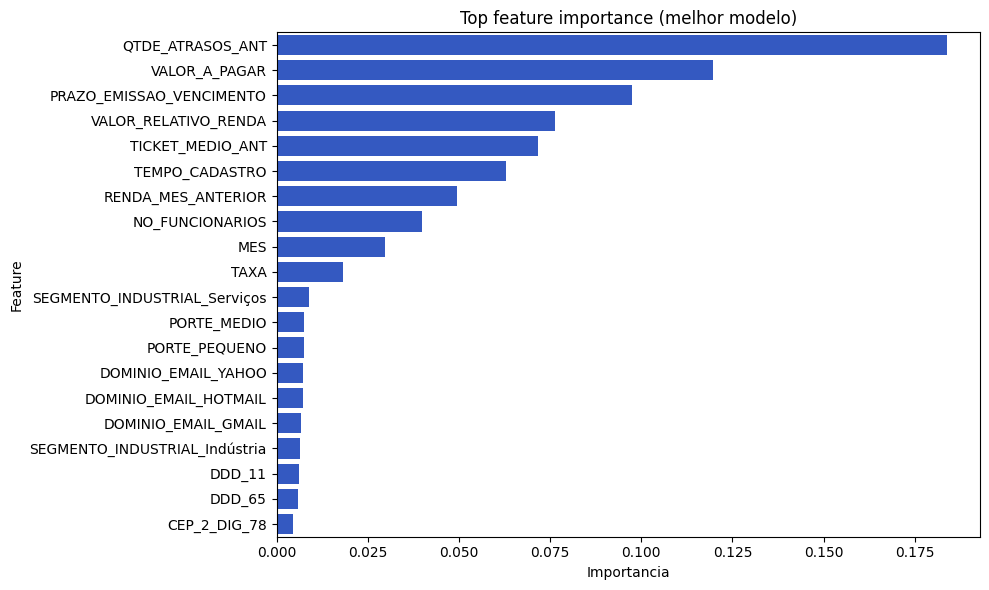

Nota: importância técnica mede contribuição preditiva no modelo; explicação de negócio depende de coerência com EDA e contexto operacional.


In [6]:
top_path = FIG_RUNS_DIR / best_run_id / 'top_features.json'
if not top_path.exists():
    top_path = ROOT / 'reports' / 'figures' / 'top_features.json'

top_feats = json.loads(top_path.read_text(encoding='utf-8'))
imp_df = pd.DataFrame(top_feats).head(20).copy()
imp_df['rank'] = np.arange(1, len(imp_df) + 1)

display(imp_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df.sort_values('importance', ascending=False), x='importance', y='feature', color='#1D4ED8')
plt.title('Top feature importance (melhor modelo)')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('Nota: importância técnica mede contribuição preditiva no modelo; explicação de negócio depende de coerência com EDA e contexto operacional.')


In [7]:
from IPython.display import Markdown, display

story_path = METRICS_DIR / 'stakeholder_story.json'
if story_path.exists():
    story = json.loads(story_path.read_text(encoding='utf-8'))
    stories = story.get('stories', [])[:5]
else:
    story = {}
    stories = []

display(Markdown('## Storytelling com EDA'))

if not stories:
    display(Markdown('Não foi encontrado `stakeholder_story.json`. Rode `python -m src.evaluate` para gerar os story plots.'))
else:
    for i, item in enumerate(stories, start=1):
        feat = item.get('feature', f'feature_{i}')
        img = item.get('image', '')
        eda_sum = item.get('eda_summary', '')
        biz = item.get('business_message', '')

        display(Markdown(f"### {i}. {feat}"))
        if img and Path(img).exists():
            display(Markdown(f"![]({img})"))
        display(Markdown(
            f"**O que apareceu no modelo:** `{feat}` entre as features mais relevantes.\n\n"
            f"**O que foi visto na EDA:** {eda_sum}\n\n"
            f"**O que isso significa para negócio:** {biz}"
        ))


## Storytelling com EDA

### 1. QTDE_ATRASOS_ANT

![](../reports/figures/story/story_QTDE_ATRASOS_ANT.png)

**O que apareceu no modelo:** `QTDE_ATRASOS_ANT` entre as features mais relevantes.

**O que foi visto na EDA:** Na EDA, a taxa de inadimplência aumenta ao longo dos quantis de QTDE_ATRASOS_ANT. Ela vai de ~1.9% para ~32.4%, diferença de ~30.6%.

**O que isso significa para negócio:** QTDE_ATRASOS_ANT é um sinal útil: quando QTDE_ATRASOS_ANT muda, o risco tende a aumenta. Isso ajuda a priorizar cobranças com maior chance de inadimplência.

### 2. VALOR_A_PAGAR

...

![](../reports/figures/story/story_VALOR_RELATIVO_RENDA.png)

**O que apareceu no modelo:** `VALOR_RELATIVO_RENDA` entre as features mais relevantes.

**O que foi visto na EDA:** Na EDA, a taxa de inadimplência diminui ao longo dos quantis de VALOR_RELATIVO_RENDA. Ela vai de ~22.9% para ~9.0%, diferença de ~13.9%.

**O que isso significa para negócio:** VALOR_RELATIVO_RENDA é um sinal útil: quando VALOR_RELATIVO_RENDA muda, o risco tende a diminui. Isso ajuda a priorizar cobranças com maior chance de inadimplência.

### 5. TICKET_MEDIO_ANT

![](../reports/figures/story/story_TICKET_MEDIO_ANT.png)

**O que apareceu no modelo:** `TICKET_MEDIO_ANT` entre as features mais relevantes.

**O que foi visto na EDA:** Na EDA, a taxa de inadimplência diminui ao longo dos quantis de TICKET_MEDIO_ANT. Ela vai de ~18.5% para ~3.7%, diferença de ~14.9%.

**O que isso significa para negócio:** TICKET_MEDIO_ANT é um sinal útil: quando TICKET_MEDIO_ANT muda, o risco tende a diminui. Isso ajuda a priorizar cobranças com maior chance de inadimplência.

## Conclusão final da modelagem

- O modelo final foi escolhido por melhor desempenho nas métricas prioritárias para desbalanceamento (principalmente PR-AUC), com suporte de ROC-AUC e F1 no threshold otimizado.
- A Regressão Logística cumpriu papel de baseline, mas desempenho inferior indicou que relações lineares não eram suficientes para representar o problema.
- O threshold converte score em decisao operacional: thresholds menores aumentam cobertura e volume; thresholds maiores reduzem volume e tornam a acao mais seletiva.
